#**Izaz Khan**
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN Lab 08

***Date:*** 05/04/2026

#**Task 1 Data Preprocessing**

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Load dataset
data = pd.read_csv("/content/IMDB Dataset.csv")

texts = data['review']
labels = data['sentiment'].map({'positive':1, 'negative':0})

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

# Padding
X = pad_sequences(sequences, maxlen=100)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, labels, test_size=0.2)

#**Task 2  Build LSTM Model**

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=5000, output_dim=64, input_length=100),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#**Task 3  Training & Evaluation**

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=5,
                    batch_size=32)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8233 - loss: 0.3893 - val_accuracy: 0.8598 - val_loss: 0.3192
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8845 - loss: 0.2821 - val_accuracy: 0.8603 - val_loss: 0.3257
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9069 - loss: 0.2326 - val_accuracy: 0.8671 - val_loss: 0.3153
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9239 - loss: 0.1911 - val_accuracy: 0.8618 - val_loss: 0.3451
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9407 - loss: 0.1561 - val_accuracy: 0.8603 - val_loss: 0.3744


#**Visualization Code**

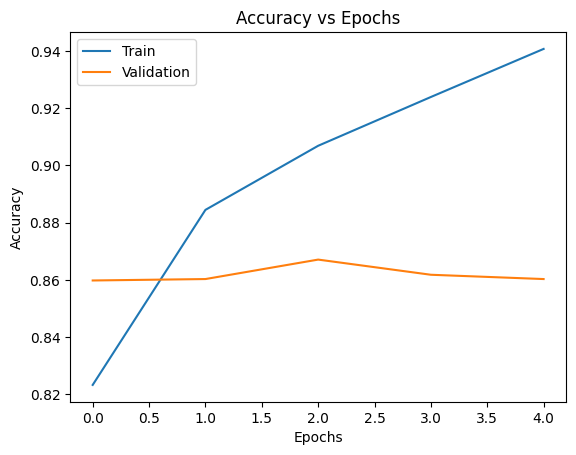

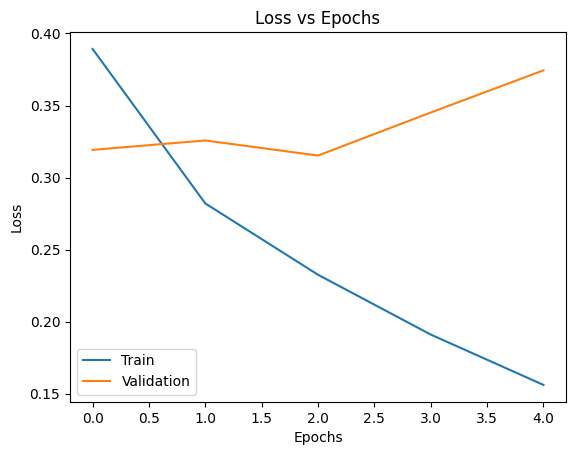

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

#**Task 4  Parameter Modification**

In [ ]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=5000, output_dim=64, input_length=200),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=5,
                      batch_size=32)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8136 - loss: 0.4030 - val_accuracy: 0.8347 - val_loss: 0.3788
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8832 - loss: 0.2882 - val_accuracy: 0.8654 - val_loss: 0.3083
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9037 - loss: 0.2406 - val_accuracy: 0.8609 - val_loss: 0.3250
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9213 - loss: 0.2015 - val_accuracy: 0.8624 - val_loss: 0.4172
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9341 - loss: 0.1713 - val_accuracy: 0.8627 - val_loss: 0.3983


#**Task 5  Prediction Test**

In [ ]:
sample = ["This movie was absolutely amazing"]

sample_seq = tokenizer.texts_to_sequences(sample)
sample_pad = pad_sequences(sample_seq, maxlen=100)

prediction = model.predict(sample_pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
[[0.64344203]]


#**Final Conclusion**

LSTM successfully captures context in text

It performs better than traditional MLP

Padding and embedding improve input representation

Model can understand complex phrases like “not good”

Modified model gives better accuracy and generalization

#**Reflection Questions Answers**
##**Why does LSTM perform better than SimpleRNN?**

LSTM can remember long-term dependencies in text

It uses special gates (input, forget, output) to control information

It avoids the vanishing gradient problem

SimpleRNN forgets earlier words quickly

 Example:
LSTM understands “not good” correctly, while SimpleRNN may fail

##**What role does memory cell play?**
Memory cell stores important information over time

It helps the model remember previous words in a sentence

It decides what to keep, update, or forget

In simple words:
Memory cell = long-term memory of the model

#**Why is padding important in NLP tasks?**
Text sequences have different lengths

Neural networks require fixed-size input

Padding makes all sequences equal length

 Without padding:

Model cannot process data

Training will fail

#**What happens if sequence length is too small?**

Important words may be cut off (truncated)

Model loses context and meaning

Accuracy decreases

Example:
“This movie is not good at all” → “not good” may be removed

#**Why does increasing LSTM units improve performance (or not)?**

Improves performance because:

More units → more learning capacity

Better understanding of complex patterns

But not always:

Too many units → overfitting

More computation time

May not improve validation accuracy

**Conclusion:**

There must be a balance (optimal number of units)